# `teamName.py` Sleeve Diagnostics

This notebook backtests the live `teamName.py` strategy on the official **test split** from `eval.py` (the last 250 days) and breaks the book into the sleeves that are currently live:

- `Core MR`
- `Pairs`
- `ALGO Fade`
- `Lead-Lag`
- `Main Book` = core + pairs + ALGO fade after the dead-band logic
- `Combined` = the exact live strategy from `teamName.py`

The `Combined` line is run through the exact `teamName.getMyPosition` implementation. The individual sleeve lines are diagnostic standalone backtests using the same evaluator commission model and limits.

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "teamName.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl")

import pandas as pd

from visualisations.teamname_sleeve_analysis import (
    BOOK_COLORS,
    run_teamname_sleeve_analysis,
    plot_suite,
)

pd.options.display.float_format = lambda x: f"{x:,.2f}"

results = run_teamname_sleeve_analysis()
results["validation"]

{'test_start_day': 250,
 'test_end_day': 499,
 'num_test_days': 250,
 'combined_max_share_diff_vs_teamname': 0}

In [2]:
summary = results["summary"].copy()
summary.style.format({
    "final_pnl": "{:,.0f}",
    "mean_daily_pl": "{:,.1f}",
    "std_daily_pl": "{:,.1f}",
    "ann_sharpe": "{:.2f}",
    "max_drawdown": "{:,.0f}",
    "turnover": "{:,.0f}",
    "commission": "{:,.0f}",
    "win_rate": "{:.1%}",
    "active_days": "{:.1%}",
    "avg_gross_exposure": "{:,.0f}",
    "trade_days": "{:,.0f}",
}).background_gradient(subset=["final_pnl", "ann_sharpe"], cmap="Greens")

,final_pnl,mean_daily_pl,std_daily_pl,ann_sharpe,max_drawdown,turnover,commission,win_rate,active_days,avg_gross_exposure,trade_days
book,,,,,,,,,,,
Combined,"158,958",635.8,"1,744.3",5.76,"-7,901","60,369,859","5,114",64.0%,100.0%,"388,599",249
Main Book,"137,176",548.7,"1,649.1",5.26,"-7,631","28,044,341","1,878",62.8%,100.0%,"277,981",249
Core MR,"70,306",281.2,"1,464.6",3.04,"-8,558","23,013,032","1,374",56.8%,100.0%,"185,284",249
Pairs,"66,525",266.1,595.4,7.07,"-2,138","5,046,976",505,67.6%,100.0%,"91,477",249
ALGO Fade,"1,544",6.2,198.3,0.49,"-2,797","1,050,223",21,50.0%,98.8%,"15,456",246
Lead-Lag,"55,941",223.8,"1,442.6",2.45,"-14,297","58,506,195","5,433",56.8%,100.0%,"225,591",249


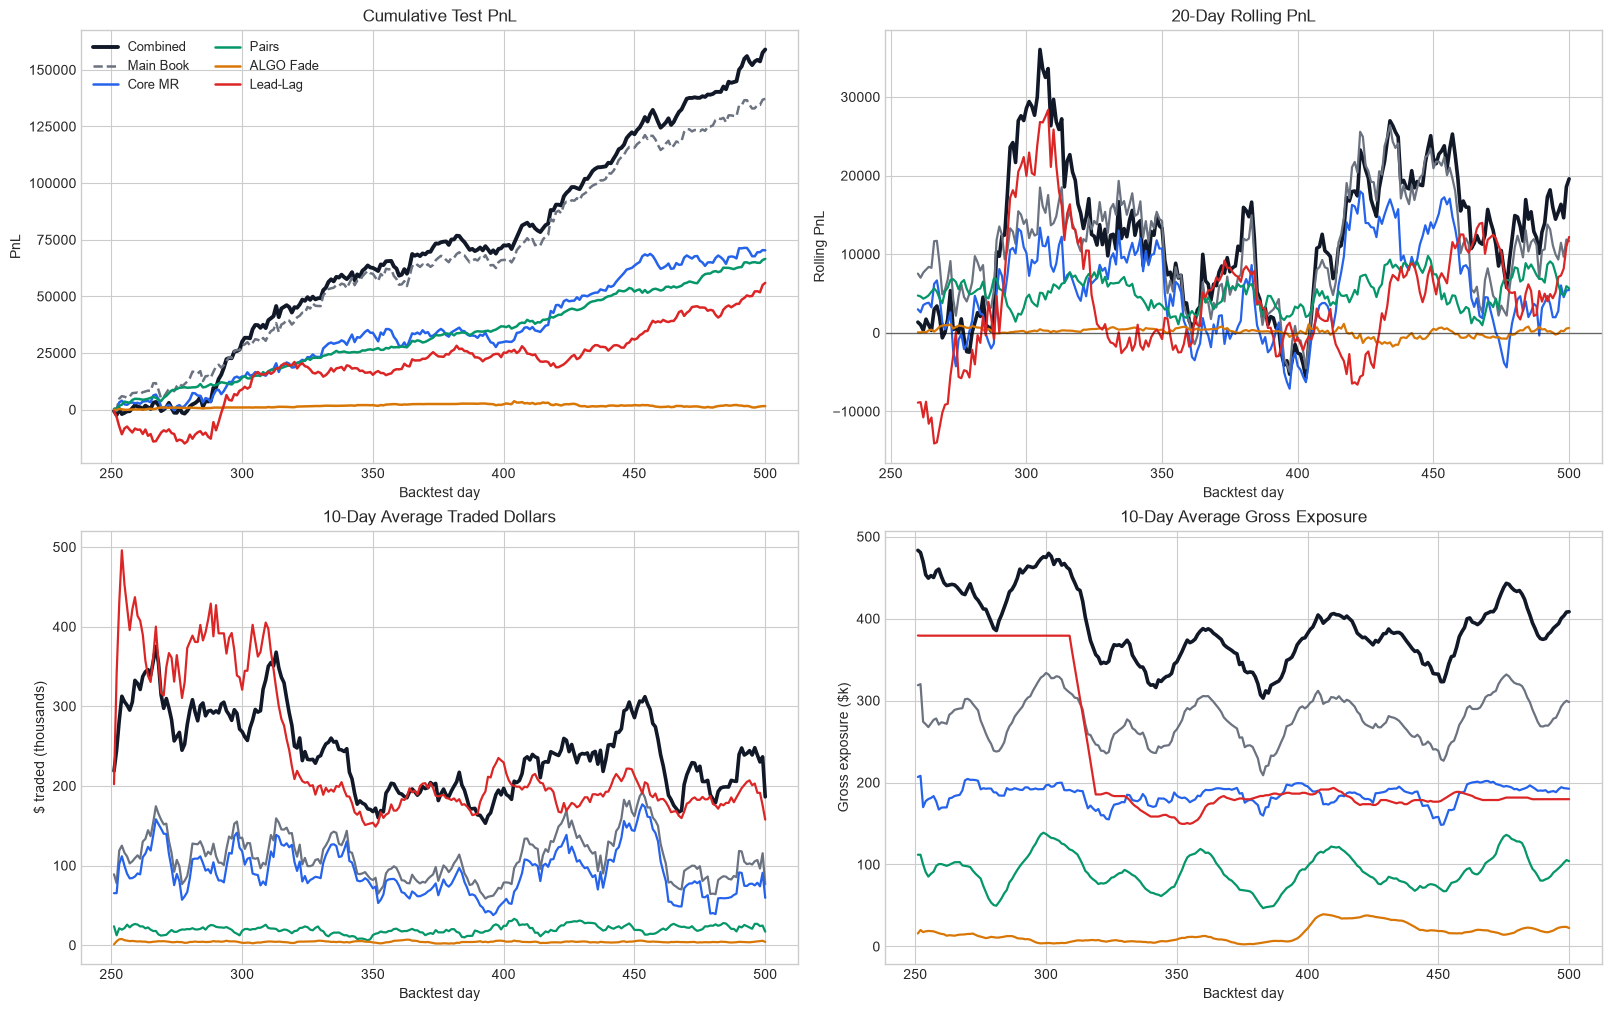

In [3]:
fig, axes = plot_suite(results, rolling_window=20)

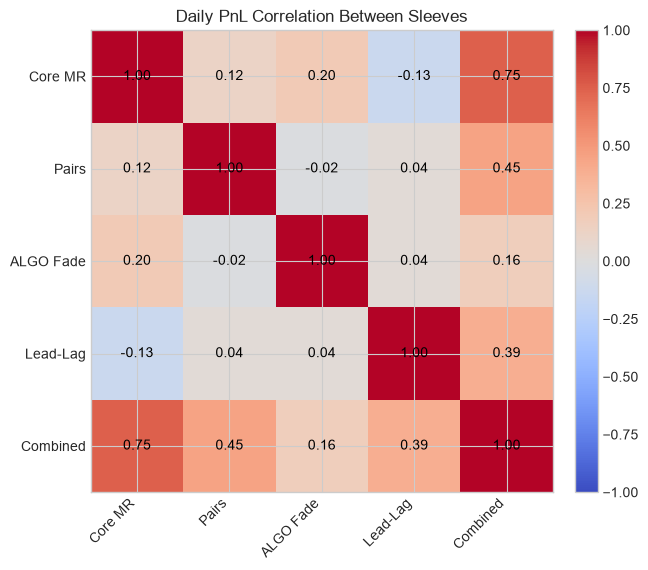

In [4]:
import matplotlib.pyplot as plt
import numpy as np

corr = results["daily_pl"][["Core MR", "Pairs", "ALGO Fade", "Lead-Lag", "Combined"]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr.index)), corr.index)
ax.set_title("Daily PnL Correlation Between Sleeves")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

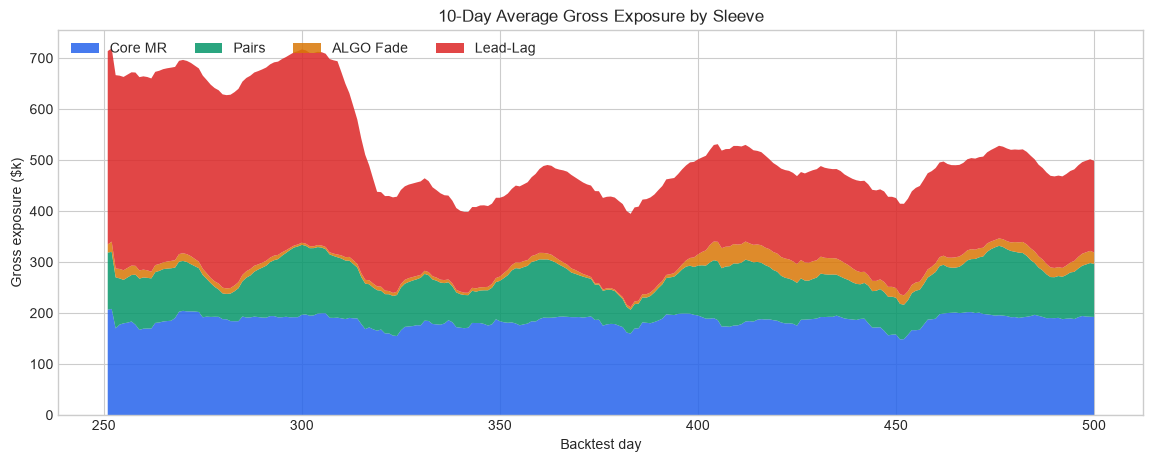

In [5]:
gross = results["gross_exposure"][["Core MR", "Pairs", "ALGO Fade", "Lead-Lag"]] / 1_000.0
gross_ma = gross.rolling(10, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    gross_ma.index,
    gross_ma.T,
    labels=gross_ma.columns,
    colors=[BOOK_COLORS[name] for name in gross_ma.columns],
    alpha=0.85,
)
ax.set_title("10-Day Average Gross Exposure by Sleeve")
ax.set_xlabel("Backtest day")
ax.set_ylabel("Gross exposure ($k)")
ax.legend(ncol=4, loc="upper left")
plt.show()